In [1]:
import sys

print(sys.executable)

c:\Users\dell\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [3]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.6


In [4]:
file_path = "../data/raw/olist_orders_dataset.csv"

orders = pd.read_csv(file_path)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.shape


(99441, 8)

In [6]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [7]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [9]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [11]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isnull()
)

order_delivered_customer_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


In [12]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [13]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [14]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders[["order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_days"]].head(10)


,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0
5,2017-07-09 21:57:05,2017-07-26 10:57:55,16.0
6,2017-04-11 12:22:08,NaT,NaN
7,2017-05-16 13:10:30,2017-05-26 12:55:51,9.0
8,2017-01-23 18:29:09,2017-02-02 14:08:10,9.0
9,2017-07-29 11:55:02,2017-08-16 17:14:30,18.0


In [15]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

orders[[
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_delay_days"
]].head(10)

,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
0,2017-10-10 21:25:13,2017-10-18,-8.0
1,2018-08-07 15:27:45,2018-08-13,-6.0
2,2018-08-17 18:06:29,2018-09-04,-18.0
3,2017-12-02 00:28:42,2017-12-15,-13.0
4,2018-02-16 18:17:02,2018-02-26,-10.0
5,2017-07-26 10:57:55,2017-08-01,-6.0
6,NaT,2017-05-09,NaN
7,2017-05-26 12:55:51,2017-06-07,-12.0
8,2017-02-02 14:08:10,2017-03-06,-32.0
9,2017-08-16 17:14:30,2017-08-23,-7.0


In [16]:
orders["delivery_status"] = "Not Delivered"

orders.loc[
    orders["delivery_delay_days"] < 0,
    "delivery_status"
] = "Early"

orders.loc[
    orders["delivery_delay_days"] == 0,
    "delivery_status"
] = "On Time"

orders.loc[
    orders["delivery_delay_days"] > 0,
    "delivery_status"
] = "Late"

orders["delivery_status"].value_counts()

delivery_status
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64

In [17]:
orders["delivery_days"].mean()

np.float64(12.094085575687217)

In [18]:
orders["delivery_days"].median()


np.float64(10.0)

In [19]:
print("Minimum delivery days:", orders["delivery_days"].min())
print("Maximum delivery days:", orders["delivery_days"].max())

Minimum delivery days: 0.0
Maximum delivery days: 209.0


In [20]:
orders[
    ["order_id", "order_status", "order_purchase_timestamp",
     "order_delivered_customer_date", "delivery_days"]
].sort_values(
    "delivery_days",
    ascending=False
).head(10)

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,209.0
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,208.0
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,195.0
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:02,2017-09-19 14:33:17,194.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,194.0
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,194.0
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,191.0
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,189.0
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,188.0
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,187.0


In [21]:
(orders["delivery_days"] > 30).sum()

np.int64(4118)

In [22]:
delivered_orders = orders[
    orders["delivery_status"] != "Not Delivered"
]

late_delivery_percentage = (
    (delivered_orders["delivery_status"] == "Late").sum()
    / len(delivered_orders)
) * 100

print("Late Delivery %:", late_delivery_percentage)

Late Delivery %: 6.773705377503212


In [23]:
orders.to_csv(
    "../data/processed/cleaned_orders.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [24]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [25]:
orders.to_csv(
    "../data/processed/cleaned_orders.csv",
    index=False
)

In [26]:
order_items = pd.read_csv(
    "../data/raw/olist_order_items_dataset.csv"
)

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [27]:
order_items.shape

(112650, 7)

In [28]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [29]:
order_items.dtypes


order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

In [30]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

order_items.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

In [31]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [32]:
order_items.duplicated().sum()

np.int64(0)

In [33]:
np.int64(0)

NameError: name 'np' is not defined

In [35]:
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [36]:
order_items["total_item_value"] = (
    order_items["price"] + order_items["freight_value"]
)

order_items[
    ["price", "freight_value", "total_item_value"]
].head()

,price,freight_value,total_item_value
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [37]:
order_items[
    ["price", "freight_value", "total_item_value"]
].head(10)

,price,freight_value,total_item_value
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04
5,21.90,12.69,34.59
6,19.90,11.85,31.75
7,810.00,70.75,880.75
8,145.95,11.65,157.60
9,53.99,11.40,65.39


In [38]:
items_per_order = order_items.groupby("order_id")["order_item_id"].count()

items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: order_item_id, dtype: float64

In [39]:
order_items.to_csv(
    "../data/processed/cleaned_order_items.csv",
    index=False
)

In [1]:
products = pd.read_csv(
    "../data/raw/olist_products_dataset.csv"
)

products.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

In [3]:
orders = pd.read_csv(
    "../data/processed/cleaned_orders.csv"
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,Early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,Early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,Early


In [4]:
order_items = pd.read_csv(
    "../data/processed/cleaned_order_items.csv"
)

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_item_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [5]:
products = pd.read_csv(
    "../data/raw/olist_products_dataset.csv"
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [6]:
products.shape

(32951, 9)

In [7]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [8]:
products.dtypes

product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [9]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [10]:
products[
    products["product_category_name"].isnull()
].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [11]:
products[
    products["product_weight_g"].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
products["product_id"].duplicated().sum()

np.int64(0)

In [13]:
products.to_csv(
    "../data/processed/cleaned_products.csv",
    index=False
)

In [14]:
category_translation = pd.read_csv(
    "../data/raw/product_category_name_translation.csv"
)

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [15]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [16]:
category_translation["product_category_name"].duplicated().sum()

np.int64(0)

In [17]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [18]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [19]:
products["product_category_name_english"].isnull().sum()

np.int64(623)

In [20]:
products[
    products["product_category_name_english"].isnull()
]["product_category_name"].value_counts(dropna=False)

product_category_name
NaN                                              610
portateis_cozinha_e_preparadores_de_alimentos     10
pc_gamer                                           3
Name: count, dtype: int64

In [21]:
products.shape

(32951, 10)

In [22]:
products.to_csv(
    "../data/processed/cleaned_products.csv",
    index=False
)

In [23]:
customers = pd.read_csv(
    "../data/raw/olist_customers_dataset.csv"
)

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [24]:
customers.shape

(99441, 5)

In [25]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [26]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [27]:
customers["customer_unique_id"].duplicated().sum()

np.int64(3345)

In [28]:
customers["customer_unique_id"].nunique()

96096

In [29]:
customers["customer_state"].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [30]:
id_duplicates = customers.duplicated().sum()
id_duplicates


np.int64(0)

In [31]:
customers.to_csv(
    "../data/processed/cleaned_customers.csv",
    index=False
)

In [32]:
sellers = pd.read_csv(
    "../data/raw/olist_sellers_dataset.csv"
)

sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [33]:
sellers.shape

(3095, 4)

In [34]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [35]:
sellers["seller_id"].duplicated().sum()

np.int64(0)

In [36]:
sellers.duplicated().sum()

np.int64(0)

In [37]:
sellers.to_csv(
    "../data/processed/cleaned_sellers.csv",
    index=False
)

In [38]:
payments = pd.read_csv(
    "../data/raw/olist_order_payments_dataset.csv"
)

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [39]:
payments.shape

(103886, 5)

In [40]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [41]:
payments.duplicated().sum()

np.int64(0)

In [42]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [43]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [44]:
payments["payment_installments"].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [45]:
payments[payments["payment_installments"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [46]:
payments[payments["payment_value"] < 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [47]:
payments.to_csv(
    "../data/processed/cleaned_payments.csv",
    index=False
)

In [48]:
reviews = pd.read_csv(
    "../data/raw/olist_order_reviews_dataset.csv"
)

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [49]:
print("Shape:", reviews.shape)
print("\nMissing values:")
print(reviews.isnull().sum())

Shape: (99224, 7)

Missing values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [50]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [51]:
reviews["review_id"].duplicated().sum()

np.int64(814)

In [52]:
reviews.duplicated().sum()

np.int64(0)

In [53]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [54]:
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

reviews.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [55]:
reviews["review_score"].min(), reviews["review_score"].max()

(np.int64(1), np.int64(5))

In [56]:
reviews.to_csv(
    "../data/processed/cleaned_reviews.csv",
    index=False
)

In [57]:
geolocation = pd.read_csv(
    "../data/raw/olist_geolocation_dataset.csv"
)

geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [58]:
print("Shape:", geolocation.shape)
print("\nMissing values:")
print(geolocation.isnull().sum())

Shape: (1000163, 5)

Missing values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [59]:
geolocation.duplicated().sum()

np.int64(261831)

In [60]:
geolocation = geolocation.drop_duplicates()

print("New shape:", geolocation.shape)

New shape: (738332, 5)


In [61]:
geolocation["geolocation_zip_code_prefix"].duplicated().sum()

np.int64(719317)

In [62]:
geolocation["geolocation_zip_code_prefix"].nunique()

19015

In [63]:
geolocation["geolocation_state"].value_counts()

geolocation_state
SP    285976
MG    101353
RJ     78836
RS     48093
PR     45059
SC     30191
BA     27720
GO     15601
PE     13162
ES     12632
CE      9541
MT      9374
DF      9080
MS      8594
PA      8551
MA      6277
PB      4787
RN      4014
PI      3592
AL      3415
TO      2977
SE      2653
RO      2523
AM      1986
AC      1039
AP       738
RR       568
Name: count, dtype: int64

In [64]:
geolocation.to_csv(
    "../data/processed/cleaned_geolocation.csv",
    index=False
)

In [65]:
geolocation.to_csv(
    "../data/processed/cleaned_geolocation.csv",
    index=False
)

In [66]:
geolocation.to_csv(
    "../data/processed/cleaned_geolocation.csv",
    index=False
)

print("Geolocation dataset saved successfully.")

Geolocation dataset saved successfully.


In [67]:
orders = pd.read_csv("../data/processed/cleaned_orders.csv")
customers = pd.read_csv("../data/processed/cleaned_customers.csv")
order_items = pd.read_csv("../data/processed/cleaned_order_items.csv")

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)

Orders: (99441, 11)
Customers: (99441, 5)
Order Items: (112650, 8)


In [68]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

print("Shape:", orders_customers.shape)
print(orders_customers.head())

Shape: (99441, 15)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:0

In [69]:
sales_data = orders_customers.merge(
    order_items,
    on="order_id",
    how="left"
)

print("Shape:", sales_data.shape)
print(sales_data.head())

Shape: (113425, 22)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:

In [70]:
print("Shape:", sales_data.shape)

print("\nMissing values:")
print(sales_data.isna().sum())

print("\nDuplicate rows:", sales_data.duplicated().sum())

Shape: (113425, 22)

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
delivery_days                    3229
delivery_delay_days              3229
delivery_status                     0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
total_item_value                  775
dtype: int64

Duplicate rows: 0


In [71]:
missing_items = sales_data[sales_data["order_item_id"].isna()]

print("Orders without items:", missing_items["order_id"].nunique())

print("\nOrder status:")
print(missing_items["order_status"].value_counts())

Orders without items: 775

Order status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [1]:
sales_transactions = sales_data[
    sales_data["order_item_id"].notna()
].copy()

print("Shape:", sales_transactions.shape)

NameError: name 'sales_data' is not defined

In [2]:
import pandas as pd

orders = pd.read_csv("../data/processed/cleaned_orders.csv")
customers = pd.read_csv("../data/processed/cleaned_customers.csv")
order_items = pd.read_csv("../data/processed/cleaned_order_items.csv")

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)

Orders: (99441, 11)
Customers: (99441, 5)
Order Items: (112650, 8)


In [3]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

print("Shape:", orders_customers.shape)

Shape: (99441, 15)


In [4]:
sales_data = orders_customers.merge(
    order_items,
    on="order_id",
    how="left"
)

print("Shape:", sales_data.shape)

Shape: (113425, 22)


In [5]:
sales_transactions = sales_data[
    sales_data["order_item_id"].notna()
].copy()

print("Shape:", sales_transactions.shape)

Shape: (112650, 22)


In [6]:
print("Shape:", sales_transactions.shape)

print("\nMissing values:")
print(sales_transactions.isna().sum())

print("\nUnique orders:", sales_transactions["order_id"].nunique())
print("Unique customers:", sales_transactions["customer_unique_id"].nunique())
print("Unique products:", sales_transactions["product_id"].nunique())

Shape: (112650, 22)

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
delivery_days                    2454
delivery_delay_days              2454
delivery_status                     0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
total_item_value                    0
dtype: int64

Unique orders: 98666
Unique customers: 95420
Unique products: 32951


In [7]:
products = pd.read_csv(
    "../data/processed/cleaned_products.csv"
)

print("Products:", products.shape)
print(products.columns.tolist())

Products: (32951, 10)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']


In [8]:
sales_transactions = sales_transactions.merge(
    products,
    on="product_id",
    how="left"
)

print("Shape:", sales_transactions.shape)
print(sales_transactions.head())

Shape: (112650, 31)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:

In [9]:
print("Shape:", sales_transactions.shape)

print("\nMissing product information:")
print(
    sales_transactions[
        ["product_category_name", "product_category_name_english"]
    ].isna().sum()
)

Shape: (112650, 31)

Missing product information:
product_category_name            1603
product_category_name_english    1627
dtype: int64


In [10]:
total_revenue = sales_transactions["total_item_value"].sum()
total_orders = sales_transactions["order_id"].nunique()
total_customers = sales_transactions["customer_unique_id"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Revenue: 15843553.24
Total Orders: 98666
Total Customers: 95420


In [11]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 160.58


In [12]:
sales_transactions.to_csv(
    "../data/processed/sales_transactions.csv",
    index=False
)

print("Sales transaction dataset saved successfully.")

Sales transaction dataset saved successfully.


In [13]:
sales_transactions["order_purchase_timestamp"] = pd.to_datetime(
    sales_transactions["order_purchase_timestamp"]
)

print(sales_transactions["order_purchase_timestamp"].dtype)

datetime64[us]


In [14]:
monthly_sales = (
    sales_transactions
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

print(monthly_sales.head())
print("\nNumber of months:", len(monthly_sales))

  order_purchase_timestamp    revenue  orders
0               2016-09-01     354.75       3
1               2016-10-01   56808.84     308
2               2016-11-01       0.00       0
3               2016-12-01      19.62       1
4               2017-01-01  137188.49     789

Number of months: 25


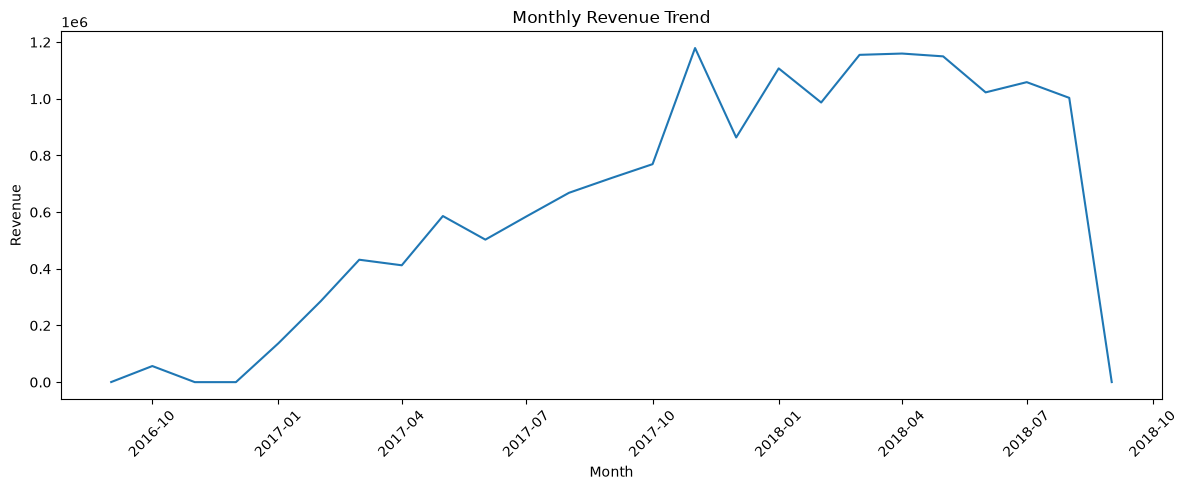

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_purchase_timestamp"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
top_months = monthly_sales.sort_values(
    "revenue",
    ascending=False
).head(10)

print(top_months)

   order_purchase_timestamp     revenue  orders
14               2017-11-01  1179143.77    7451
19               2018-04-01  1159698.04    6934
18               2018-03-01  1155126.82    7188
20               2018-05-01  1149781.82    6853
16               2018-01-01  1107301.89    7220
22               2018-07-01  1058728.03    6273
21               2018-06-01  1022677.11    6160
23               2018-08-01  1003308.47    6452
17               2018-02-01   986908.96    6694
15               2017-12-01   863547.23    5624


In [17]:
category_sales = (
    sales_transactions
    .groupby("product_category_name_english", dropna=False)
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique"),
        items=("product_id", "count")
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

print(category_sales.head(10))

  product_category_name_english     revenue  orders  items
0                 health_beauty  1441248.07    8836   9670
1                 watches_gifts  1305541.61    5624   5991
2                bed_bath_table  1241681.72    9417  11115
3                sports_leisure  1156656.48    7720   8641
4         computers_accessories  1059272.40    6689   7827
5               furniture_decor   902511.79    6449   8334
6                    housewares   778397.77    5884   6964
7                    cool_stuff   719329.95    3632   3796
8                          auto   685384.32    3897   4235
9                  garden_tools   584219.21    3518   4347


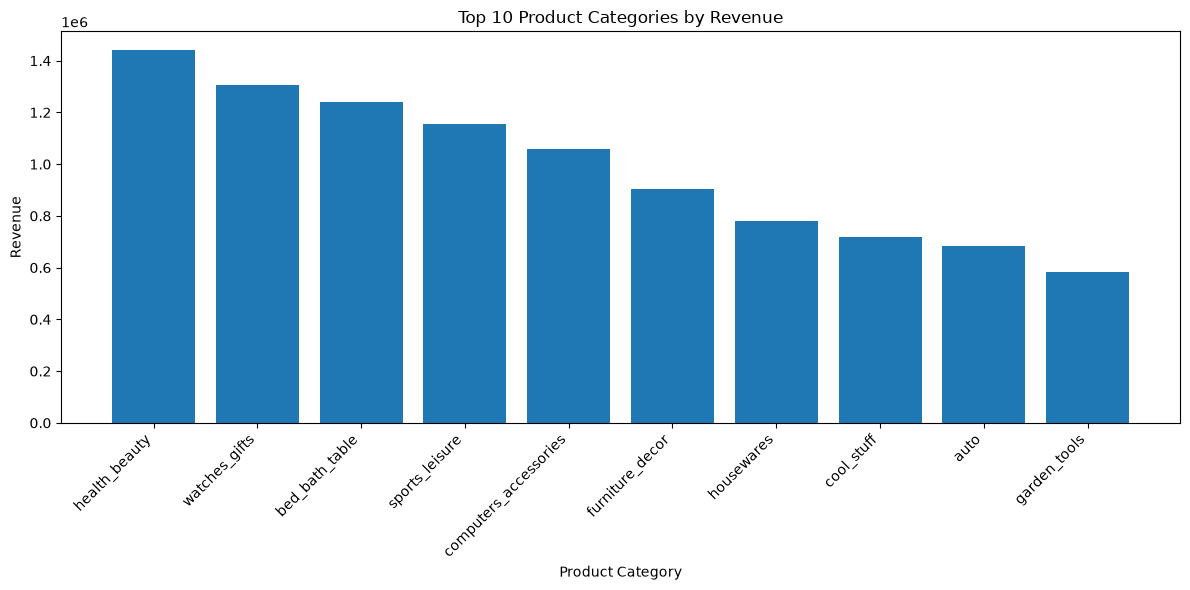

In [18]:
import matplotlib.pyplot as plt

top_categories = category_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories["product_category_name_english"],
    top_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [19]:
product_sales = (
    sales_transactions
    .groupby("product_id")
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique"),
        items=("product_id", "count")
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

print(product_sales.head(10))

                         product_id   revenue  orders  items
0  bb50f2e236e5eea0100680137654686c  67606.10     187    195
1  d1c427060a0f73f6b889a5c7c61f2ac4  60976.03     323    343
2  6cdd53843498f92890544667809f1595  59093.99     151    156
3  99a4788cb24856965c36a24e339b6058  51071.60     467    488
4  d6160fb7873f184099d9bc95e30376af  50326.18      35     35
5  3dd2a17168ec895c781a9191c1e95ad7  48212.22     255    274
6  aca2eb7d00ea1a7b8ebd4e68314663af  44820.76     431    527
7  5f504b3a1c75b73d6151be81eb05bdc9  41725.81      63     63
8  25c38557cf793876c5abdd5931f922db  40311.95      38     38
9  53b36df67ebb7c41585e8d54d6772e08  39957.93     306    323


In [20]:
top_products = (
    product_sales
    .head(10)
    .merge(
        products[
            ["product_id", "product_category_name_english"]
        ],
        on="product_id",
        how="left"
    )
)

print(top_products)

                         product_id   revenue  orders  items  \
0  bb50f2e236e5eea0100680137654686c  67606.10     187    195   
1  d1c427060a0f73f6b889a5c7c61f2ac4  60976.03     323    343   
2  6cdd53843498f92890544667809f1595  59093.99     151    156   
3  99a4788cb24856965c36a24e339b6058  51071.60     467    488   
4  d6160fb7873f184099d9bc95e30376af  50326.18      35     35   
5  3dd2a17168ec895c781a9191c1e95ad7  48212.22     255    274   
6  aca2eb7d00ea1a7b8ebd4e68314663af  44820.76     431    527   
7  5f504b3a1c75b73d6151be81eb05bdc9  41725.81      63     63   
8  25c38557cf793876c5abdd5931f922db  40311.95      38     38   
9  53b36df67ebb7c41585e8d54d6772e08  39957.93     306    323   

  product_category_name_english  
0                 health_beauty  
1         computers_accessories  
2                 health_beauty  
3                bed_bath_table  
4                     computers  
5         computers_accessories  
6               furniture_decor  
7                    co

In [21]:
print(top_products)


                         product_id   revenue  orders  items  \
0  bb50f2e236e5eea0100680137654686c  67606.10     187    195   
1  d1c427060a0f73f6b889a5c7c61f2ac4  60976.03     323    343   
2  6cdd53843498f92890544667809f1595  59093.99     151    156   
3  99a4788cb24856965c36a24e339b6058  51071.60     467    488   
4  d6160fb7873f184099d9bc95e30376af  50326.18      35     35   
5  3dd2a17168ec895c781a9191c1e95ad7  48212.22     255    274   
6  aca2eb7d00ea1a7b8ebd4e68314663af  44820.76     431    527   
7  5f504b3a1c75b73d6151be81eb05bdc9  41725.81      63     63   
8  25c38557cf793876c5abdd5931f922db  40311.95      38     38   
9  53b36df67ebb7c41585e8d54d6772e08  39957.93     306    323   

  product_category_name_english  
0                 health_beauty  
1         computers_accessories  
2                 health_beauty  
3                bed_bath_table  
4                     computers  
5         computers_accessories  
6               furniture_decor  
7                    co

In [22]:
payment_analysis = (
    payments
    .groupby("payment_type")
    .agg(
        payment_value=("payment_value", "sum"),
        orders=("order_id", "nunique"),
        transactions=("payment_type", "count")
    )
    .sort_values("payment_value", ascending=False)
    .reset_index()
)

print(payment_analysis)

NameError: name 'payments' is not defined

In [23]:
import pandas as pd

payments = pd.read_csv(
    "../data/processed/cleaned_payments.csv"
)

print(payments.shape)

(103886, 5)


In [24]:
payment_analysis = (
    payments
    .groupby("payment_type")
    .agg(
        payment_value=("payment_value", "sum"),
        orders=("order_id", "nunique"),
        transactions=("payment_type", "count")
    )
    .sort_values("payment_value", ascending=False)
    .reset_index()
)

print(payment_analysis)

  payment_type  payment_value  orders  transactions
0  credit_card    12542084.19   76505         76795
1       boleto     2869361.27   19784         19784
2      voucher      379436.87    3866          5775
3   debit_card      217989.79    1528          1529
4  not_defined           0.00       3             3


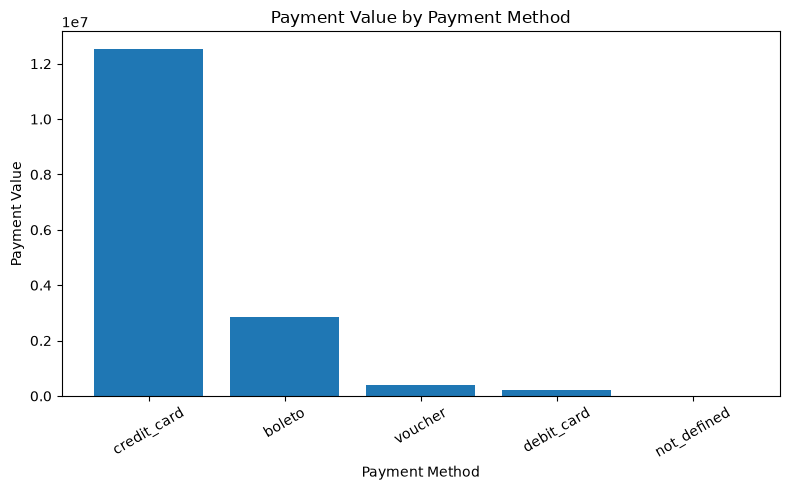

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_analysis["payment_type"],
    payment_analysis["payment_value"]
)

plt.title("Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Payment Value")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [26]:
customer_state = (
    customers
    .groupby("customer_state")
    .agg(
        customers=("customer_unique_id", "nunique")
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

print(customer_state.head(10))

  customer_state  customers
0             SP      40302
1             RJ      12384
2             MG      11259
3             RS       5277
4             PR       4882
5             SC       3534
6             BA       3277
7             DF       2075
8             ES       1964
9             GO       1952


In [27]:
state_sales = (
    sales_transactions
    .groupby("customer_state")
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

print(state_sales.head(10))

  customer_state     revenue  orders  customers
0             SP  5921678.12   41375      39981
1             RJ  2129681.98   12762      12303
2             MG  1856161.49   11544      11178
3             RS   885826.76    5432       5249
4             PR   800935.44    4998       4840
5             BA   611506.67    3358       3257
6             SC   610213.60    3612       3513
7             DF   353229.44    2125       2062
8             GO   347706.93    2007       1942
9             ES   324801.91    2025       1956


In [28]:
state_sales["revenue_per_customer"] = (
    state_sales["revenue"] / state_sales["customers"]
)

state_sales = state_sales.sort_values(
    "revenue_per_customer",
    ascending=False
)

print(state_sales.head(10))

   customer_state    revenue  orders  customers  revenue_per_customer
15             PB  140987.81     532        516            273.232190
24             AC   19669.70      81         77            255.450649
22             RO   57558.02     247        235            244.927745
25             AP   16262.80      68         67            242.728358
19             AL   96229.40     411        399            241.176441
12             PA  217647.11     970        944            230.558379
21             TO   61354.42     279        272            225.567721
17             PI  108132.28     493        481            224.807235
26             RR   10064.62      46         45            223.658222
18             RN  101895.08     482        471            216.337749


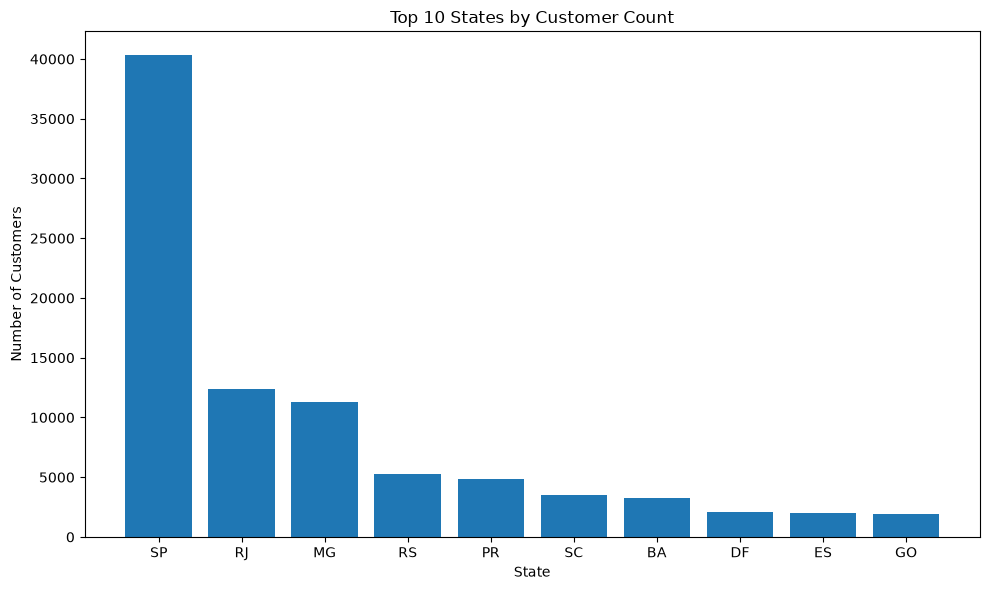

In [29]:
top_customer_states = (
    customer_state
    .sort_values("customers", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_customer_states["customer_state"],
    top_customer_states["customers"]
)

plt.title("Top 10 States by Customer Count")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [30]:
orders = pd.read_csv(
    "../data/processed/cleaned_orders.csv"
)

print(orders["delivery_status"].value_counts())

delivery_status
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64


In [31]:
delivery_summary = (
    orders["delivery_status"]
    .value_counts()
    .reset_index()
)

delivery_summary.columns = ["delivery_status", "orders"]

delivery_summary["percentage"] = (
    delivery_summary["orders"]
    / delivery_summary["orders"].sum()
    * 100
)

print(delivery_summary)

  delivery_status  orders  percentage
0           Early   88649   89.147334
1            Late    6535    6.571736
2   Not Delivered    2965    2.981668
3         On Time    1292    1.299263


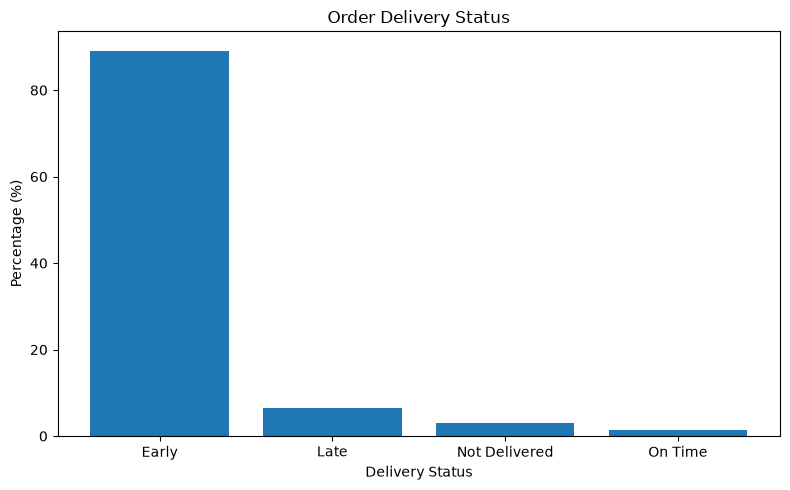

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    delivery_summary["delivery_status"],
    delivery_summary["percentage"]
)

plt.title("Order Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

In [33]:
delivery_time = orders["delivery_days"].dropna()

print("Average Delivery Days:", round(delivery_time.mean(), 2))
print("Median Delivery Days:", delivery_time.median())
print("Minimum Delivery Days:", delivery_time.min())
print("Maximum Delivery Days:", delivery_time.max())

Average Delivery Days: 12.09
Median Delivery Days: 10.0
Minimum Delivery Days: 0.0
Maximum Delivery Days: 209.0


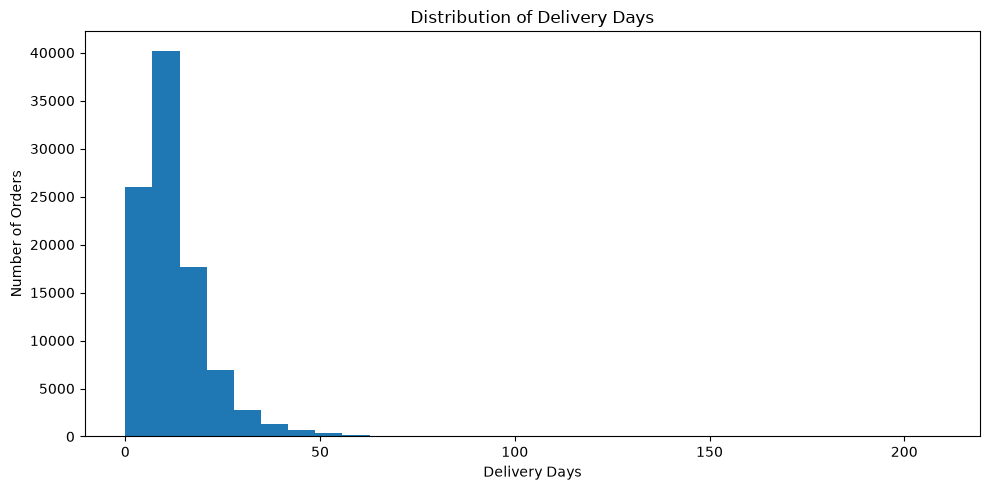

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(
    delivery_time,
    bins=30
)

plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [35]:
within_7_days = (delivery_time <= 7).mean() * 100
within_14_days = (delivery_time <= 14).mean() * 100
within_30_days = (delivery_time <= 30).mean() * 100

print("Delivered within 7 days:", round(within_7_days, 2), "%")
print("Delivered within 14 days:", round(within_14_days, 2), "%")
print("Delivered within 30 days:", round(within_30_days, 2), "%")

Delivered within 7 days: 34.93 %
Delivered within 14 days: 72.66 %
Delivered within 30 days: 95.73 %


In [36]:
state_delivery = (
    orders
    .groupby(orders["customer_state"])
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "count")
    )
    .reset_index()
)

state_delivery = state_delivery.sort_values(
    "average_delivery_days",
    ascending=False
)

print(state_delivery.head(10))

KeyError: 'customer_state'

In [37]:
order_delivery_state = (
    sales_transactions[
        ["order_id", "customer_state", "delivery_days"]
    ]
    .drop_duplicates("order_id")
)

state_delivery = (
    order_delivery_state
    .groupby("customer_state")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "count")
    )
    .reset_index()
    .sort_values("average_delivery_days", ascending=False)
)

print(state_delivery.head(10))

   customer_state  average_delivery_days  orders
21             RR              28.975610      46
3              AP              26.731343      68
2              AM              25.986207     147
1              AL              24.040302     411
13             PA              23.316068     970
9              MA              21.117155     740
24             SE              21.029851     345
5              CE              20.817826    1327
0              AC              20.637500      81
14             PB              19.953578     532


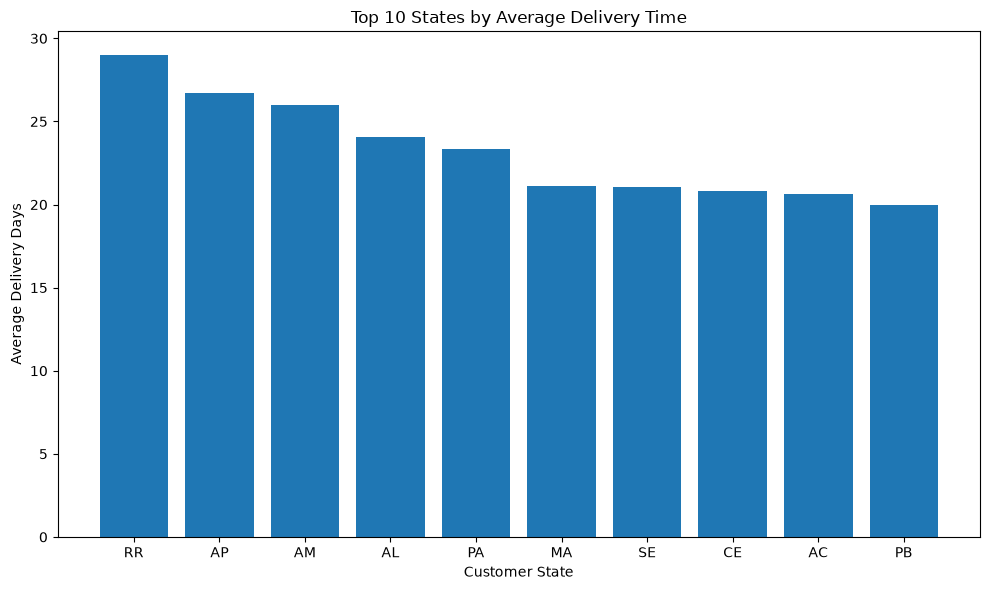

In [38]:
top_delivery_states = state_delivery.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_delivery_states["customer_state"],
    top_delivery_states["average_delivery_days"]
)

plt.title("Top 10 States by Average Delivery Time")
plt.xlabel("Customer State")
plt.ylabel("Average Delivery Days")

plt.tight_layout()
plt.show()

In [39]:
customer_orders = (
    sales_transactions
    .groupby("customer_unique_id")
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("total_item_value", "sum")
    )
    .reset_index()
)

print(customer_orders.head())
print("Number of customers:", customer_orders.shape[0])

                 customer_unique_id       last_purchase  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:27          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:27          1     27.19
2  0000f46a3911fa3c0805444483337064 2017-03-10 21:05:03          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078 2017-10-12 20:29:41          1     43.62
4  0004aac84e0df4da2b147fca70cf8255 2017-11-14 19:45:42          1    196.89
Number of customers: 95420


In [40]:
reference_date = sales_transactions["order_purchase_timestamp"].max()

customer_orders["recency"] = (
    reference_date - customer_orders["last_purchase"]
).dt.days

print("Reference Date:", reference_date)
print(customer_orders[["customer_unique_id", "last_purchase", "recency"]].head())

Reference Date: 2018-09-03 09:06:57
                 customer_unique_id       last_purchase  recency
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:27      115
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:27      118
2  0000f46a3911fa3c0805444483337064 2017-03-10 21:05:03      541
3  0000f6ccb0745a6a4b88665a16c9f078 2017-10-12 20:29:41      325
4  0004aac84e0df4da2b147fca70cf8255 2017-11-14 19:45:42      292


In [41]:
print("Average Recency:", round(customer_orders["recency"].mean(), 2))
print("Median Recency:", customer_orders["recency"].median())
print("Minimum Recency:", customer_orders["recency"].min())
print("Maximum Recency:", customer_orders["recency"].max())

Average Recency: 242.6
Median Recency: 223.0
Minimum Recency: 0
Maximum Recency: 728


In [42]:
print("Average Frequency:", round(customer_orders["frequency"].mean(), 2))
print("Median Frequency:", customer_orders["frequency"].median())
print("Minimum Frequency:", customer_orders["frequency"].min())
print("Maximum Frequency:", customer_orders["frequency"].max())


Average Frequency: 1.03
Median Frequency: 1.0
Minimum Frequency: 1
Maximum Frequency: 16


In [43]:
print("Average Monetary Value:", round(customer_orders["monetary"].mean(), 2))
print("Median Monetary Value:", round(customer_orders["monetary"].median(), 2))
print("Minimum Monetary Value:", round(customer_orders["monetary"].min(), 2))
print("Maximum Monetary Value:", round(customer_orders["monetary"].max(), 2))

Average Monetary Value: 166.04
Median Monetary Value: 107.94
Minimum Monetary Value: 9.59
Maximum Monetary Value: 13664.08


In [44]:
customer_orders["R_score"] = pd.qcut(
    customer_orders["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

customer_orders["F_score"] = pd.qcut(
    customer_orders["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

customer_orders["M_score"] = pd.qcut(
    customer_orders["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

print(
    customer_orders[
        ["customer_unique_id", "recency", "frequency", "monetary",
         "R_score", "F_score", "M_score"]
    ].head(10)
)

                 customer_unique_id  recency  frequency  monetary R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      115          1    141.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      118          1     27.19       4   
2  0000f46a3911fa3c0805444483337064      541          1     86.22       1   
3  0000f6ccb0745a6a4b88665a16c9f078      325          1     43.62       2   
4  0004aac84e0df4da2b147fca70cf8255      292          1    196.89       2   
5  0004bd2a26a76fe21f786e4fbd80607f      150          1    166.98       4   
6  00050ab1314c0e55a6ca13cf7181fecf      135          1     35.38       4   
7  00053a61a98854899e70ed204dd4bafe      186          1    419.18       3   
8  0005e1862207bf6ccc02e4228effd9a0      547          1    150.12       1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      174          1    129.76       4   

  F_score M_score  
0       1       4  
1       1       1  
2       1       2  
3       1       1  
4       1       4  
5       1       4  
6       1   

In [45]:
customer_orders["RFM_score"] = (
    customer_orders["R_score"].astype(str)
    + customer_orders["F_score"].astype(str)
    + customer_orders["M_score"].astype(str)
)

print(
    customer_orders[
        ["customer_unique_id", "R_score", "F_score", "M_score", "RFM_score"]
    ].head(10)
)

                 customer_unique_id R_score F_score M_score RFM_score
0  0000366f3b9a7992bf8c76cfdf3221e2       4       1       4       414
1  0000b849f77a49e4a4ce2b2a4ca5be3f       4       1       1       411
2  0000f46a3911fa3c0805444483337064       1       1       2       112
3  0000f6ccb0745a6a4b88665a16c9f078       2       1       1       211
4  0004aac84e0df4da2b147fca70cf8255       2       1       4       214
5  0004bd2a26a76fe21f786e4fbd80607f       4       1       4       414
6  00050ab1314c0e55a6ca13cf7181fecf       4       1       1       411
7  00053a61a98854899e70ed204dd4bafe       3       1       5       315
8  0005e1862207bf6ccc02e4228effd9a0       1       1       4       114
9  0005ef4cd20d2893f0d9fbd94d3c0d97       4       1       3       413


In [46]:
rfm_distribution = (
    customer_orders["RFM_score"]
    .value_counts()
    .sort_index()
)

print(rfm_distribution)

RFM_score
111     813
112     820
113     797
114     720
115     742
       ... 
551     663
552     687
553     719
554     804
555    1036
Name: count, Length: 125, dtype: int64


In [47]:
def create_segment(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "New Customers"

    elif r >= 3 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Lost Customers"

    else:
        return "Need Attention"


customer_orders["customer_segment"] = customer_orders.apply(
    create_segment,
    axis=1
)

print(
    customer_orders[
        ["customer_unique_id", "RFM_score", "customer_segment"]
    ].head(10)
)

                 customer_unique_id RFM_score     customer_segment
0  0000366f3b9a7992bf8c76cfdf3221e2       414        New Customers
1  0000b849f77a49e4a4ce2b2a4ca5be3f       411        New Customers
2  0000f46a3911fa3c0805444483337064       112       Lost Customers
3  0000f6ccb0745a6a4b88665a16c9f078       211       Lost Customers
4  0004aac84e0df4da2b147fca70cf8255       214       Lost Customers
5  0004bd2a26a76fe21f786e4fbd80607f       414        New Customers
6  00050ab1314c0e55a6ca13cf7181fecf       411        New Customers
7  00053a61a98854899e70ed204dd4bafe       315  Potential Loyalists
8  0005e1862207bf6ccc02e4228effd9a0       114       Lost Customers
9  0005ef4cd20d2893f0d9fbd94d3c0d97       413        New Customers


In [48]:
segment_summary = (
    customer_orders["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["customer_segment", "customers"]

segment_summary["percentage"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum()
    * 100
)

print(segment_summary)

      customer_segment  customers  percentage
0       Need Attention      22638   23.724586
1       Lost Customers      15335   16.071054
2        New Customers      15283   16.016558
3      Loyal Customers      14496   15.191784
4              At Risk      13492   14.139593
5  Potential Loyalists       7550    7.912387
6            Champions       6626    6.944037


In [49]:
segment_revenue = (
    customer_orders
    .groupby("customer_segment")
    .agg(
        customers=("customer_unique_id", "count"),
        revenue=("monetary", "sum"),
        average_customer_value=("monetary", "mean")
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

print(segment_revenue)

      customer_segment  customers     revenue  average_customer_value
0              At Risk      13492  3317049.09              245.853031
1      Loyal Customers      14496  3005971.79              207.365604
2        New Customers      15283  2511239.76              164.315891
3       Lost Customers      15335  2506545.41              163.452586
4            Champions       6626  2085942.90              314.811787
5       Need Attention      22638  1248365.32               55.144682
6  Potential Loyalists       7550  1168438.97              154.760128


In [50]:
segment_revenue["revenue_percentage"] = (
    segment_revenue["revenue"]
    / segment_revenue["revenue"].sum()
    * 100
)

print(segment_revenue)

      customer_segment  customers     revenue  average_customer_value  \
0              At Risk      13492  3317049.09              245.853031   
1      Loyal Customers      14496  3005971.79              207.365604   
2        New Customers      15283  2511239.76              164.315891   
3       Lost Customers      15335  2506545.41              163.452586   
4            Champions       6626  2085942.90              314.811787   
5       Need Attention      22638  1248365.32               55.144682   
6  Potential Loyalists       7550  1168438.97              154.760128   

   revenue_percentage  
0           20.936270  
1           18.972839  
2           15.850231  
3           15.820601  
4           13.165878  
5            7.879327  
6            7.374854  


In [51]:
customer_orders.to_csv(
    "../data/processed/customer_rfm.csv",
    index=False
)

print("RFM customer data saved successfully.")

RFM customer data saved successfully.


In [1]:
import pandas as pd

reviews = pd.read_csv("../data/processed/cleaned_reviews.csv")

print("Reviews loaded:", len(reviews))

Reviews loaded: 99224


In [2]:
import csv

reviews.to_csv(
    "../data/processed/reviews_for_oracle.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)

print("Oracle-ready reviews file created")

Oracle-ready reviews file created


In [3]:
import pandas as pd
import csv

# Replace line breaks inside review text
reviews["review_comment_title"] = (
    reviews["review_comment_title"]
    .fillna("")
    .astype(str)
    .str.replace("\r", " ", regex=False)
    .str.replace("\n", " ", regex=False)
)

reviews["review_comment_message"] = (
    reviews["review_comment_message"]
    .fillna("")
    .astype(str)
    .str.replace("\r", " ", regex=False)
    .str.replace("\n", " ", regex=False)
)

# Create Oracle-friendly CSV
reviews.to_csv(
    "../data/processed/reviews_oracle_final.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)

print("Oracle-friendly reviews file created")
print("Rows:", len(reviews))

Oracle-friendly reviews file created
Rows: 99224
